# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.estimators import *
from core.dgp import *
from core.experiments import *
from core.visualization import *

# Experiments

In [13]:
# parameters
train_size = 500
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

# train estimators 
# plugin estimator
plugin_estmr = BinaryPlugIn(dgp.group_func, num_groups).fit(train_x, train_t, train_y)

# value correction estimator
vc_estmr = BinaryValueCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500)
# value correction estimator with m-out-of-n bootstrap 
mnbvc_estmr = BinaryMNBValueCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.9, max_j=20)  
# value correction estimator with numerical bootstrap
nbvc_estmr = BinaryNBValueCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, epsilon_n_pow=-0.45)

# error correction estimator
ec_estmr = BinaryErrorCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500)
# error correction estimator with m-out-of-n bootstrap 
mnbec_estmr = BinaryMNBErrorCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.95, max_j=20) 
# error correction estimator with numerical bootstrap
nbec_estmr = BinaryNBErrorCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, epsilon_n_pow=-0.45)

In [14]:
# evalute test set 
budget = 1
# plugin estimator and its performance
plugin_targ_est = plugin_estmr.estimate_targeting_value(test_x, budget=budget)
true_plugin_targ_val = evaluate_targeting_policy(test_x, plugin_estmr.get_targeting_decision(test_x, budget), dgp, budget=budget)
# value correction estimators
vc_targ_est = vc_estmr.estimate_targeting_value(test_x, budget=budget)
mnbvc_targ_est = mnbvc_estmr.estimate_targeting_value(test_x, budget=budget)
nbvc_targ_est = nbvc_estmr.estimate_targeting_value(test_x, budget=budget)
# error correction estimators
ec_targ_est = ec_estmr.estimate_targeting_value(test_x, budget=budget, resid_method=3)
mnbec_targ_est = mnbec_estmr.estimate_targeting_value(test_x, budget=budget, resid_method=3)
nbec_targ_est = nbec_estmr.estimate_targeting_value(test_x, budget=budget, resid_method=3)

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Error Correction targeting estimate: {ec_targ_est:.4f}")
print(f"Error Correction with M-out-of-n Bootstrap targeting estimate: {mnbec_targ_est:.4f}")
print(f"Error Correction with numerical bootstrap targeting estimate: {nbec_targ_est:.4f}")
print(f"Value Correction targeting estimate: {vc_targ_est:.4f}")
print(f"Value Correction with M-out-of-n Bootstrap targeting estimate: {mnbvc_targ_est:.4f}")
print(f"Value Correction with numerical bootstrap targeting estimate: {nbvc_targ_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of error correction estimate: {ec_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of error correction with M-out-of-n bootstrap estimate: {mnbec_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of value correction estimate: {vc_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of value correction with M-out-of-n bootstrap estimate: {mnbvc_targ_est - true_plugin_targ_val:.4f}")

Plugin targeting estimate: 1.3046
Error Correction targeting estimate: 1.2898
Error Correction with M-out-of-n Bootstrap targeting estimate: 1.2810
Error Correction with numerical bootstrap targeting estimate: 1.2698
Value Correction targeting estimate: 1.2908
Value Correction with M-out-of-n Bootstrap targeting estimate: 1.2200
Value Correction with numerical bootstrap targeting estimate: 1.2576

Actual value of plugin targeting: 1.1000
Winner's Curse of plugin estimate: 0.2046
Winner's Curse of error correction estimate: 0.1898
Winner's Curse of error correction with M-out-of-n bootstrap estimate: 0.1810
Winner's Curse of value correction estimate: 0.1908
Winner's Curse of value correction with M-out-of-n bootstrap estimate: 0.1200


## Test 1

In [15]:
# parameters
dgp_params = {
    'num_groups': 2,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 2.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'error_correction': {
        'estimator': BinaryErrorCorrection, 
        'train_params': {'n_bootstraps': 500}, 
        'targeting_params': {'resid_method': 2}, 
    },  # error correction estimator
    'mnb_error_correction': {
        'estimator': BinaryMNBErrorCorrection, 
        'train_params': {'n_bootstraps': 500, 'q': 0.96, 'max_j': 20}, 
        'targeting_params': {'resid_method': 3}, 
    },  # error correction estimator with m-out-of-n bootstrap
    'nb_error_correction': {
        'estimator': BinaryNBErrorCorrection, 
        'train_params': {'n_bootstraps': 500, 'epsilon_n_pow': -0.47}, 
        'targeting_params': {'resid_method': 3}, 
    },  # error correction estimator with numerical bootstrap
    'value_correction': {
        'estimator': BinaryValueCorrection, 
        'train_params': {'n_bootstraps': 500}, 
        'targeting_params': {}, 
    },  # value correction estimator
    'mnb_value_correction': {
        'estimator': BinaryMNBValueCorrection, 
        'train_params': {'n_bootstraps': 500, 'q': 0.96, 'max_j': 20}, 
        'targeting_params': {}, 
    },  # value correction estimator with m-out-of-n bootstrap
    'nb_value_correction': {
        'estimator': BinaryNBValueCorrection, 
        'train_params': {'n_bootstraps': 500, 'epsilon_n_pow': -0.47}, 
        'targeting_params': {}, 
    },  # value correction estimator with numerical bootstrap
}

In [12]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000],
    num_bootstraps=[500],
    noise_stds=[3.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/sample_size_test.csv',
    num_test_groups=25, num_repeats_per_test_group=25, 
    verbose=True
)

Fixed knob values: 
num_bootstrap=500
noise_std=3.0
te_diff=0.1
sample_size=100.0, Time taken: 0:07:25.657201
sample_size=200.0, Time taken: 0:08:19.542785
sample_size=300.0, Time taken: 0:09:35.226690
sample_size=400.0, Time taken: 0:10:17.266728
sample_size=500.0, Time taken: 0:11:24.896545
sample_size=750.0, Time taken: 0:14:57.168536
sample_size=1000.0, Time taken: 0:17:02.375906
sample_size=1500.0, Time taken: 0:23:03.400833
sample_size=2000.0, Time taken: 0:27:51.251101
sample_size=2500.0, Time taken: 0:35:47.487268
sample_size=3000.0, Time taken: 0:40:27.530883


Fixed Knobs:  sample_size: 500, num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

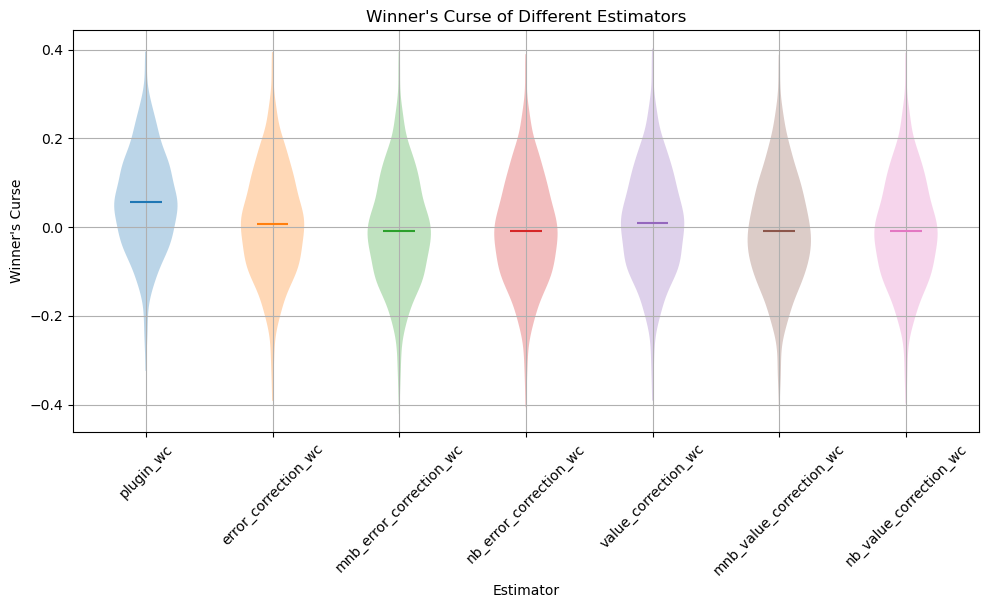

In [10]:
plot_winners_curse_violin(
    result_dir='results/sample_size_test.csv', sample_size=500
)

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

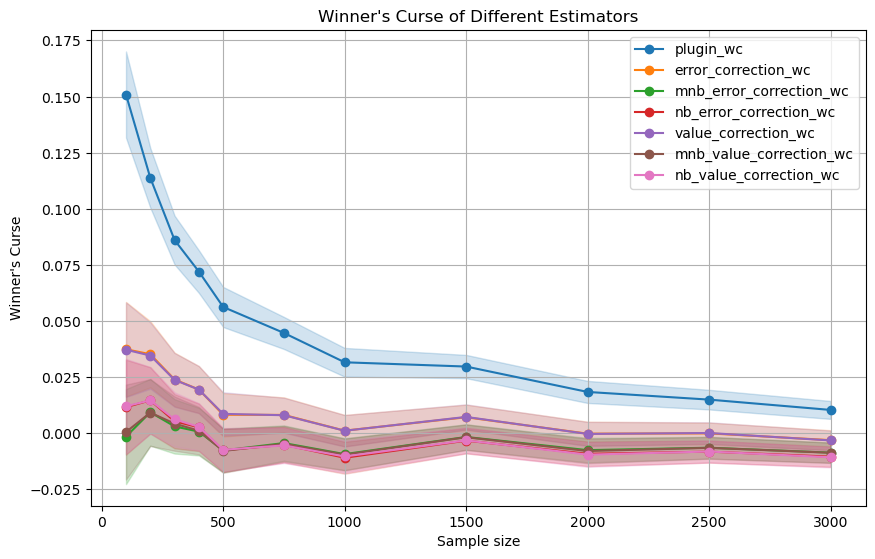

In [11]:
plot_winners_curse_2d(
    result_dir='results/sample_size_test.csv', x='sample_size', confidence_level=0.95, 
)

In [27]:
grid_results = grid_experiment(
    sample_sizes=[500], 
    num_bootstraps=[200],
    noise_stds=[1.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/te_diff_test.csv',
    num_test_groups=25, num_repeats_per_test_group=25, 
    verbose=True
)

Fixed knob values: 
sample_size=500
num_bootstrap=200
noise_std=1.0
te_diff=0.05, Time taken: 0:11:55.203950
te_diff=0.1, Time taken: 0:11:13.277267
te_diff=0.15, Time taken: 0:10:55.968152
te_diff=0.2, Time taken: 0:10:54.665729
te_diff=0.25, Time taken: 0:11:02.872212
te_diff=0.3, Time taken: 0:10:58.887811
te_diff=0.35, Time taken: 0:10:55.991559
te_diff=0.4, Time taken: 0:10:55.903779
te_diff=0.45, Time taken: 0:10:57.098301
te_diff=0.5, Time taken: 0:10:55.877187


Fixed Knobs:  sample_size: 500.0, num_bootstrap: 200.0, noise_std: 1.0, 

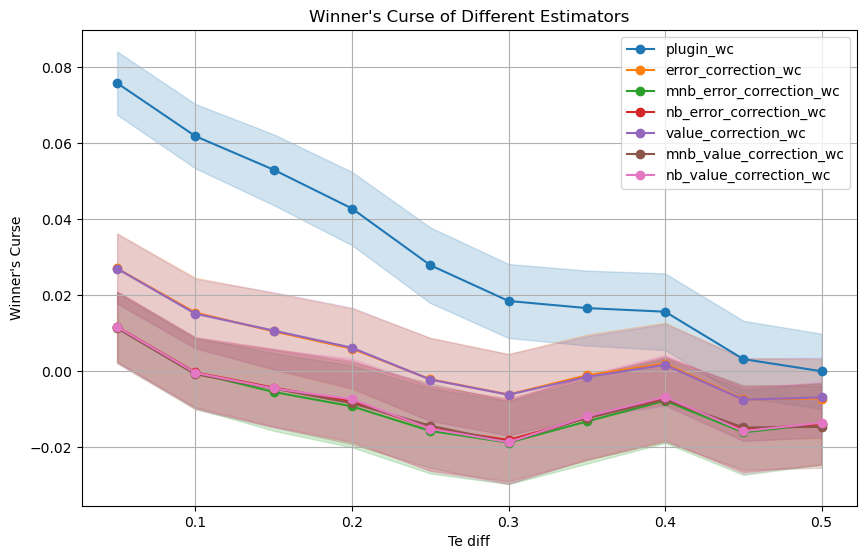

In [28]:
plot_winners_curse_2d(
    result_dir='results/te_diff_test.csv', x='te_diff', confidence_level=0.95, 
)

In [29]:
grid_results = grid_experiment(
    sample_sizes=[500], 
    num_bootstraps=[200],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/noise_std_test.csv',
    num_test_groups=25, num_repeats_per_test_group=25, 
    verbose=True
)

Fixed knob values: 
sample_size=500
num_bootstrap=200
te_diff=0.1
noise_std=0.5, Time taken: 0:10:59.071884
noise_std=1.0, Time taken: 0:10:58.250373
noise_std=1.5, Time taken: 0:10:53.518435
noise_std=2.0, Time taken: 0:10:53.663478
noise_std=2.5, Time taken: 0:10:51.329804
noise_std=3.0, Time taken: 0:10:52.695435
noise_std=3.5, Time taken: 0:10:55.445093
noise_std=4.0, Time taken: 0:10:53.805310
noise_std=4.5, Time taken: 0:10:53.443664
noise_std=5.0, Time taken: 0:10:54.333234


Fixed Knobs:  sample_size: 500.0, num_bootstrap: 200.0, te_diff: 0.1, 

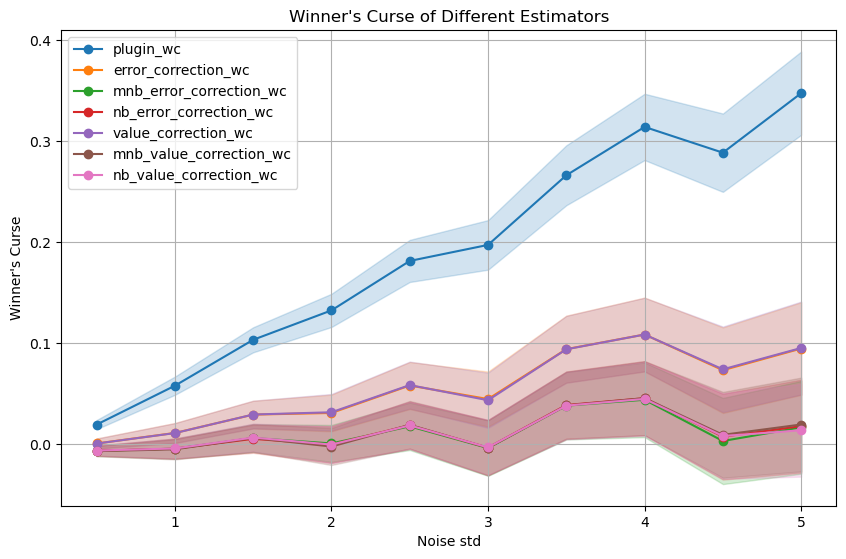

In [30]:
plot_winners_curse_2d(
    result_dir='results/noise_std_test.csv', x='noise_std', confidence_level=0.95, 
)

## Test 2

In [ ]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
# parameters
dgp_params = {
    'num_groups': 4,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': group_func,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # adjusted bootstrap correction estimator, 
}

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000], 
    num_bootstraps=[500],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid2.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 5000, Time taken: 169.08 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 338.05 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 518.35 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 686.76 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 175.74 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 361.12 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 541.05 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 717.27 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 186.74 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 2289.31 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 1538.88 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 775.34 seconds
Sample size: 1500, Num bootstrap: 5000, Time taken: 197.85 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 399.24 seconds
Sample size: 1500, Num bootstrap: 15000, Time taken: 607.1

# Sketch

In [14]:
# parameters
train_size = 100
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

In [36]:
mnb_corr_estimator = BinaryMNBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.95, max_j=20)  # m-out-of-n bootstrap correction estimator

In [37]:
mnb_corr_estimator.estimate_targeting_value(test_x, budget=budget)

1.148269749177544